# 🚗 Egyptian Car Plates — Character Recognition (YOLOv8)

## 1️⃣ Install & Import

In [1]:
!pip install ultralytics -q --no-deps
!pip install opencv-python-headless PyYAML scipy matplotlib pandas psutil py-cpuinfo -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.8 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import cv2
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import torch

print(f'✅ PyTorch: {torch.__version__}')
print(f'✅ CUDA available: {torch.cuda.is_available()}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ PyTorch: 2.10.0+cu128
✅ CUDA available: True


## 2️⃣ Label Map & Configuration

In [3]:
# ── Same label_map from original CRNN notebook ───────────────────────────
label_map = {
    "0": "0", "1": "1", "2": "2", "3": "3", "4": "4",
    "5": "5", "6": "6", "7": "7", "8": "8", "9": "9",
    "zero": "0", "one": "1", "two": "2", "three": "3", "four": "4",
    "five": "5", "six": "6", "seven": "7", "eight": "8", "nine": "9",
    "alif": "ا", "baa": "ب", "taa": "ت", "thaa": "ث", "jeem": "ج",
    "7aa": "ح", "khaa": "خ", "daal": "د", "zaal": "ذ", "raa": "ر",
    "zay": "ز", "seen": "س", "sheen": "ش", "saad": "ص", "daad": "ض",
    "taa_cap": "ط", "tah": "ط", "zaa": "ظ", "ain": "ع", "ghayn": "غ",
    "faa": "ف", "qaaf": "ق", "kaaf": "ك", "laam": "ل", "meem": "م",
    "noon": "ن", "haa": "ه", "waw": "و", "yaa": "ي",
    "ا": "ا", "ب": "ب", "ت": "ت", "ث": "ث", "ج": "ج",
    "ح": "ح", "خ": "خ", "د": "د", "ذ": "ذ", "ر": "ر",
    "ز": "ز", "س": "س", "ش": "ش", "ص": "ص", "ض": "ض",
    "ط": "ط", "ظ": "ظ", "ع": "ع", "غ": "غ", "ف": "ف",
    "ق": "ق", "ك": "ك", "ل": "ل", "م": "م", "ن": "ن",
    "ه": "ه", "و": "و", "ي": "ي"
}

# ── Get unique classes (sorted for consistent indexing) ──────────────────
unique_classes = sorted(set(label_map.values()))
CLASS_TO_IDX   = {c: i for i, c in enumerate(unique_classes)}
IDX_TO_CLASS   = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES    = len(unique_classes)

print(f'📊 Total classes: {NUM_CLASSES}')
print(f'   Classes: {unique_classes}')

# ── Paths ────────────────────────────────────────────────────────────────
BASE_PATH = '/kaggle/input/datasets/alyalsayed/egyptian-car-plates'
SPLITS = {
    'train': {'csv': f'{BASE_PATH}/train/_annotations.csv', 'imgs': f'{BASE_PATH}/train/'},
    'val':   {'csv': f'{BASE_PATH}/valid/_annotations.csv', 'imgs': f'{BASE_PATH}/valid/'},
    'test':  {'csv': f'{BASE_PATH}/test/_annotations.csv',  'imgs': f'{BASE_PATH}/test/'},
}

# ── YOLO dataset dir ─────────────────────────────────────────────────────
YOLO_DIR   = Path('/kaggle/working/yolo_chars')
IMG_SIZE   = 640
BATCH_SIZE = 16
EPOCHS     = 50

for split in ['train', 'val', 'test']:
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

print(f'✅ Config ready!')

📊 Total classes: 38
   Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'ا', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']
✅ Config ready!


## 3️⃣ Convert CSV Annotations → YOLO Format

> CSV has `x1, y1, x2, y2` (pixel coords) per character.  
> YOLO needs `class cx cy w h` (normalized 0-1).

In [4]:
def normalize_label(raw_label):
    """Map raw CSV label → unified class string."""
    s = str(raw_label).strip()
    if s == 'Taa':
        s = 'tah'
    else:
        s = s.lower()
    return label_map.get(s, None)


def convert_split(split_name, csv_path, img_dir):
    """Read CSV, copy images, write YOLO label .txt files."""
    df = pd.read_csv(
        csv_path,
        names=['name', 'x1', 'y1', 'x2', 'y2', 'label'],
        header=0
    )

    skipped = 0
    processed_imgs = set()

    for img_name, group in df.groupby('name'):
        src = os.path.join(img_dir, img_name)
        if not os.path.exists(src):
            skipped += 1
            continue

        img = cv2.imread(src)
        if img is None:
            skipped += 1
            continue

        h, w = img.shape[:2]
        lines = []

        for _, row in group.iterrows():
            cls = normalize_label(row['label'])
            if cls is None:
                continue
            cls_idx = CLASS_TO_IDX[cls]

            x1, y1, x2, y2 = float(row['x1']), float(row['y1']), float(row['x2']), float(row['y2'])
            cx = ((x1 + x2) / 2) / w
            cy = ((y1 + y2) / 2) / h
            bw = (x2 - x1) / w
            bh = (y2 - y1) / h

            # Clamp to [0, 1]
            cx = max(0.0, min(1.0, cx))
            cy = max(0.0, min(1.0, cy))
            bw = max(0.001, min(1.0, bw))
            bh = max(0.001, min(1.0, bh))

            lines.append(f'{cls_idx} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')

        if not lines:
            skipped += 1
            continue

        # Copy image
        dst_img = YOLO_DIR / 'images' / split_name / img_name
        shutil.copy(src, dst_img)

        # Write label
        label_name = Path(img_name).stem + '.txt'
        dst_lbl = YOLO_DIR / 'labels' / split_name / label_name
        with open(dst_lbl, 'w') as f:
            f.write('\n'.join(lines))

        processed_imgs.add(img_name)

    print(f'  [{split_name}] ✅ {len(processed_imgs)} images | ⚠️ {skipped} skipped')


print('🔄 Converting annotations...')
for split_name, cfg in SPLITS.items():
    convert_split(split_name, cfg['csv'], cfg['imgs'])

print('✅ Done!')

🔄 Converting annotations...
  [train] ✅ 2606 images | ⚠️ 0 skipped
  [val] ✅ 745 images | ⚠️ 0 skipped
  [test] ✅ 371 images | ⚠️ 0 skipped
✅ Done!


In [5]:
# ── Write data.yaml ──────────────────────────────────────────────────────
data_yaml = {
    'path'  : str(YOLO_DIR),
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : NUM_CLASSES,
    'names' : unique_classes
}

yaml_path = YOLO_DIR / 'data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print('📄 data.yaml:')
print(open(yaml_path, encoding='utf-8').read())

📄 data.yaml:
names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- '8'
- '9'
- ا
- ب
- ت
- ث
- ج
- ح
- خ
- د
- ذ
- ر
- ز
- س
- ش
- ص
- ض
- ط
- ظ
- ع
- غ
- ف
- ق
- ك
- ل
- م
- ن
- ه
- و
- ي
nc: 38
path: /kaggle/working/yolo_chars
test: images/test
train: images/train
val: images/val



## 4️⃣ Visualize Sample Annotations

/tmp/ipykernel_57/2756897141.py:41: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


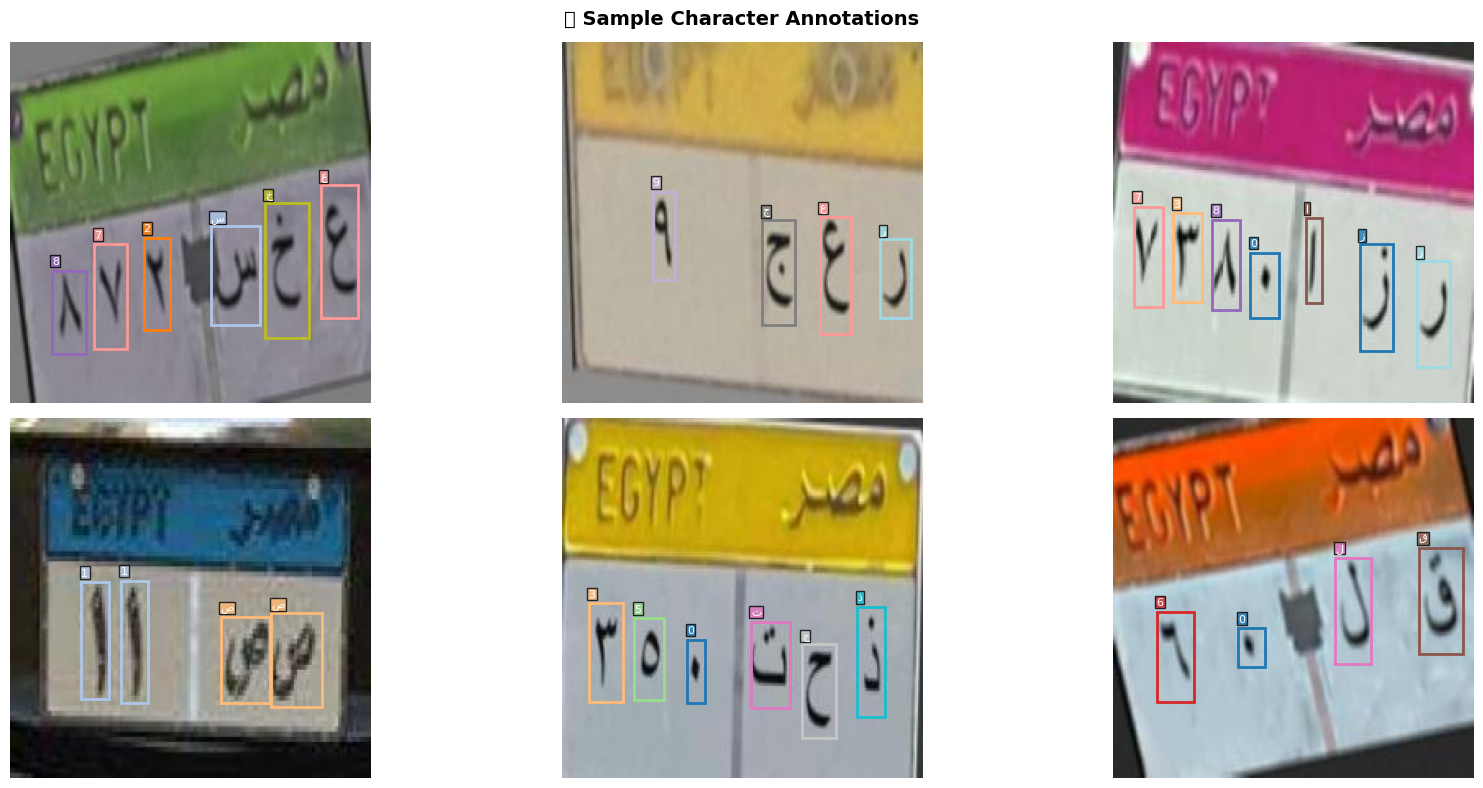

In [6]:
def show_annotated(img_path, label_path, ax):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    colors = plt.cm.tab20.colors
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_idx = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            color = colors[cls_idx % len(colors)]
            rect = patches.Rectangle(
                (x1, y1), bw*w, bh*h,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, IDX_TO_CLASS[cls_idx],
                    color='white', fontsize=8,
                    bbox=dict(facecolor=color, alpha=0.8, pad=1))
    ax.axis('off')


train_imgs = list((YOLO_DIR / 'images' / 'train').glob('*.jpg')) + \
             list((YOLO_DIR / 'images' / 'train').glob('*.png'))

samples = random.sample(train_imgs, min(6, len(train_imgs)))
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('🔍 Sample Character Annotations', fontsize=14, fontweight='bold')

for ax, img_p in zip(axes.flat, samples):
    lbl_p = YOLO_DIR / 'labels' / 'train' / (img_p.stem + '.txt')
    if lbl_p.exists():
        show_annotated(img_p, lbl_p, ax)

plt.tight_layout()
plt.show()

## 5️⃣ Train YOLOv8

| Parameter | Value | Notes |
|-----------|-------|-------|
| Model | `yolov8n` | Nano — fast, good for small chars |
| imgsz | 640 | Standard |
| epochs | 50 | Early stopping patience=10 |
| Classes | ~39 | Arabic letters + digits |

In [7]:
model = YOLO('yolov8n.pt')

results = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    patience  = 10,
    device    = 0,
    project   = '/kaggle/working/runs',
    name      = 'chars_yolov8',
    exist_ok  = True,
    # ── Augmentation ────────────────────────────────────
    hsv_h     = 0.015,
    hsv_s     = 0.5,
    hsv_v     = 0.4,
    degrees   = 3.0,       # لوحات مش بتتقلبش كتير
    translate = 0.1,
    scale     = 0.4,
    flipud    = 0.0,
    fliplr    = 0.0,       # الحروف لو اتعكست بتبقى غلط
    mosaic    = 1.0,
    mixup     = 0.0,
)

print('✅ Training complete!')

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_chars/data.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=chars_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

## 6️⃣ Evaluation

In [8]:
best_model_path = '/kaggle/working/runs/chars_yolov8/weights/best.pt'
best_model = YOLO(best_model_path)

metrics = best_model.val(
    data     = str(yaml_path),
    split    = 'test',
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    device   = 0,
    project  = '/kaggle/working/runs',
    name     = 'chars_yolov8_eval',
    exist_ok = True,
)

print('\n📊 Test Set Metrics:')
print(f'  mAP@50     : {metrics.box.map50:.4f}')
print(f'  mAP@50-95  : {metrics.box.map:.4f}')
print(f'  Precision  : {metrics.box.mp:.4f}')
print(f'  Recall     : {metrics.box.mr:.4f}')

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,013,058 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 172.5±55.3 MB/s, size: 4.9 KB)
val: Scanning /kaggle/working/yolo_chars/labels/test... 371 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 371/371 1.3Kit/s 0.3s<0.1s
val: New cache created: /kaggle/working/yolo_chars/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 5.9it/s 4.0s0.1s
                   all        371       1964      0.973      0.987      0.989      0.648
                     0         59         71      0.889      0.905      0.938      0.389
                     1        115        156      0.976      0.981      0.988       0.56
                     2         76         97       0.99       0.99      0.994      0.661
                     3         68         72      0.964          1      0

/tmp/ipykernel_57/75952552.py:30: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


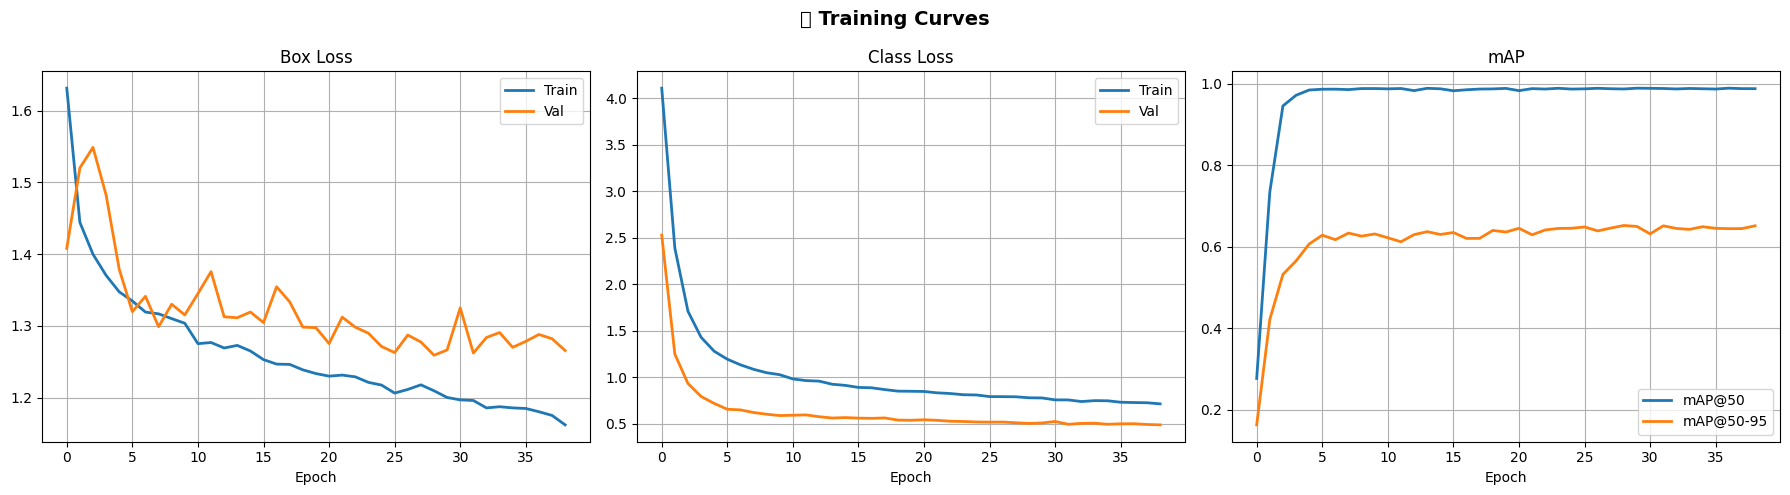

In [9]:
results_csv = '/kaggle/working/runs/chars_yolov8/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📈 Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(df['train/box_loss'], label='Train', linewidth=2)
axes[0].plot(df['val/box_loss'],   label='Val',   linewidth=2)
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df['train/cls_loss'], label='Train', linewidth=2)
axes[1].plot(df['val/cls_loss'],   label='Val',   linewidth=2)
axes[1].set_title('Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(df['metrics/mAP50(B)'],    label='mAP@50',    linewidth=2)
axes[2].plot(df['metrics/mAP50-95(B)'], label='mAP@50-95', linewidth=2)
axes[2].set_title('mAP')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 7️⃣ Read Plate Text 

In [14]:
def read_plate_text(plate_img_path, model, conf=0.3, iou=0.4):
    """
    Input : path to a CROPPED plate image (output of YOLO #1)
    Output: plate text in English/Standard (Left-to-Right)
    """
    res = model.predict(
        source  = plate_img_path,
        conf    = conf,
        iou     = iou,
        imgsz   = IMG_SIZE,
        verbose = False
    )[0]

    if len(res.boxes) == 0:
        return "No characters detected", []

    boxes  = res.boxes.xyxy.cpu().numpy()   # x1 y1 x2 y2
    confs  = res.boxes.conf.cpu().numpy()
    clsids = res.boxes.cls.cpu().numpy().astype(int)

    order = np.argsort(boxes[:, 0])
    boxes, confs, clsids = boxes[order], confs[order], clsids[order]

    chars = [IDX_TO_CLASS[i] for i in clsids]
    plate_text = ' '.join(chars)

    detections = [
        {'char': chars[i], 'conf': confs[i], 'box': boxes[i]}
        for i in range(len(chars))
    ]

    return plate_text, detections


def visualize_plate_reading(plate_img_path, model, conf=0.3):
    """Show the plate with detected characters annotated."""
    text, detections = read_plate_text(plate_img_path, model, conf)

    img = cv2.imread(str(plate_img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab20.colors

    axes[0].imshow(img)
    for d in detections:
        x1, y1, x2, y2 = d['box']
        cls = d['char']
        color = colors[CLASS_TO_IDX[cls] % len(colors)]
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        axes[0].add_patch(rect)
        axes[0].text(x1, y1-5, f'{cls} {d["conf"]:.2f}',
                     color='white', fontsize=9,
                     bbox=dict(facecolor=color, alpha=0.8, pad=1))
    axes[0].set_title('Character Detection')
    axes[0].axis('off')

    axes[1].axis('off')
    axes[1].text(0.5, 0.6, text,
                 ha='center', va='center', fontsize=28, fontweight='bold',
                 color='#2c3e50')
    axes[1].text(0.5, 0.3, f'{len(detections)} characters detected',
                 ha='center', va='center', fontsize=12, color='gray')
    
    axes[1].set_title('Plate Text (Left → Right)')
    axes[1].set_facecolor('#f8f9fa')

    plt.suptitle('🚗 License Plate Reading', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return text

/tmp/ipykernel_57/825032104.py:73: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


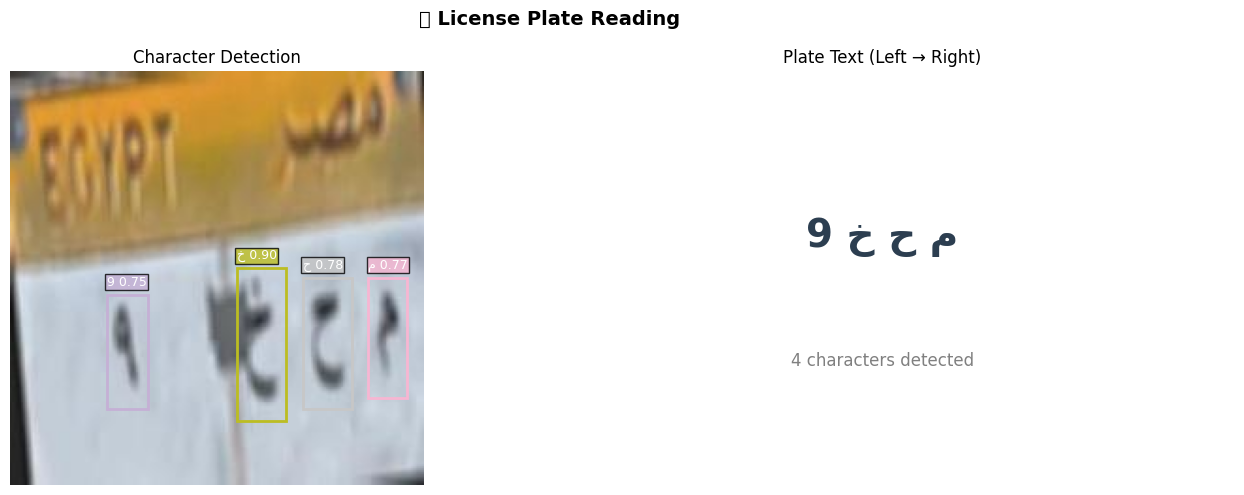

📋 00032_jpg.rf.4580899bbe3d20a5922a4f366cf47402.jpg → 9 خ ح م



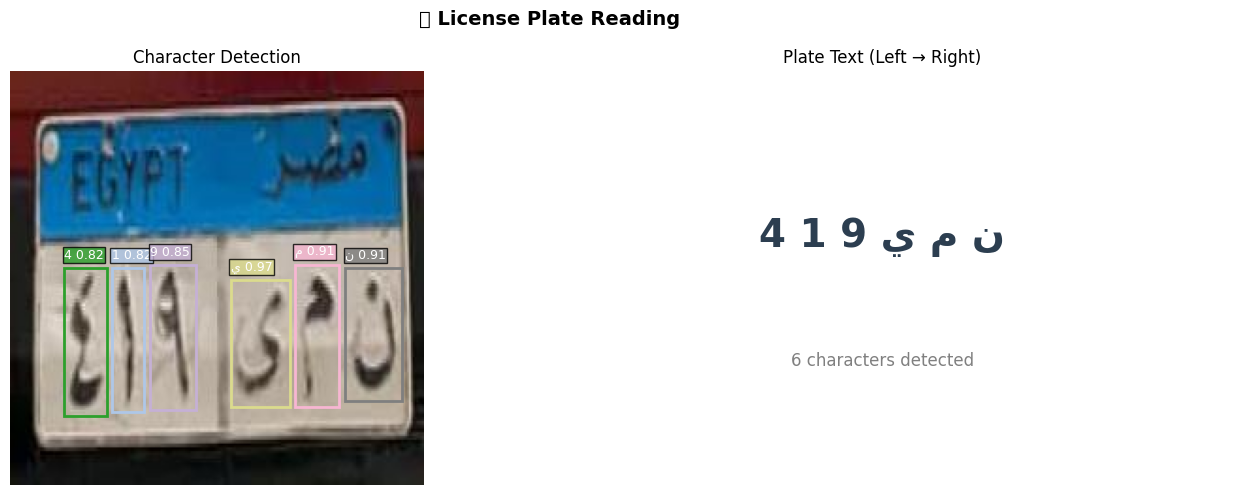

📋 1848_license_plate_1_png.rf.76d1aa9bdb18e9f196f8d13a142e6fe1.jpg → 4 1 9 ي م ن



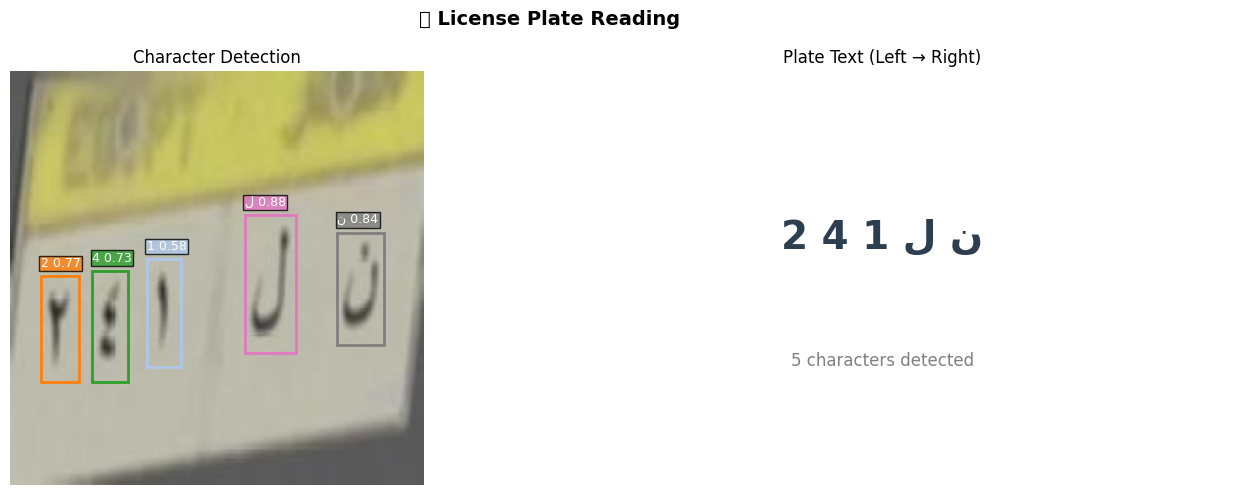

📋 02573_jpg.rf.c683b098e689d1d7c28c59eb985c94ca.jpg → 2 4 1 ل ن



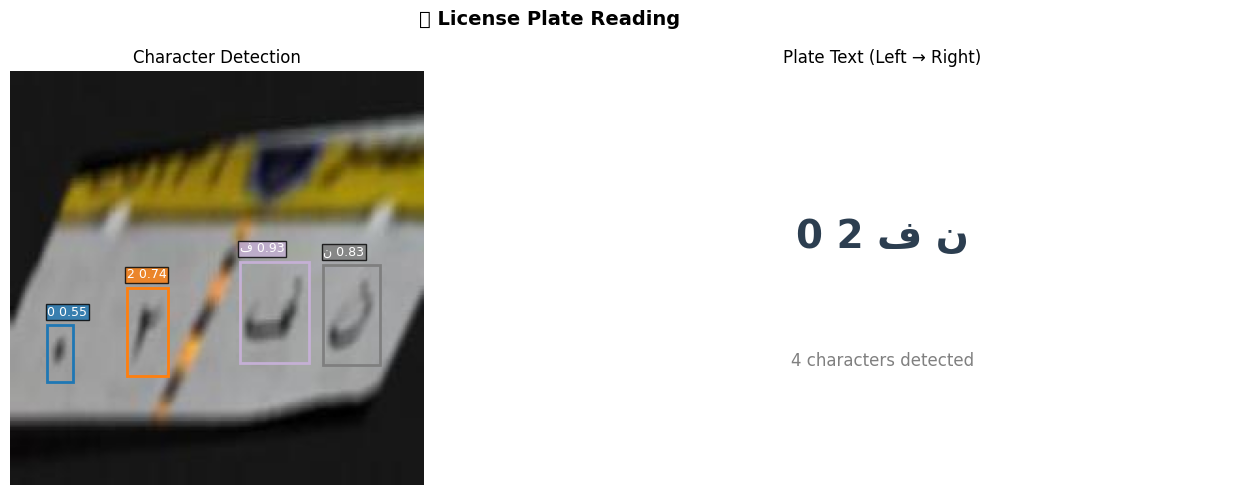

📋 01794_jpg.rf.f789f72cc3bd777a8789db21e383b981.jpg → 0 2 ف ن



In [15]:
# ── Test on sample images from test set ─────────────────────────────────
test_imgs = list((YOLO_DIR / 'images' / 'test').glob('*.jpg')) + \
            list((YOLO_DIR / 'images' / 'test').glob('*.png'))

samples = random.sample(test_imgs, min(4, len(test_imgs)))

for img_p in samples:
    text = visualize_plate_reading(str(img_p), best_model)
    print(f'📋 {img_p.name} → {text}\n')

## 9️⃣ Export Model

In [13]:
best_model.export(format='onnx', imgsz=IMG_SIZE)
print(f'✅ ONNX exported!')
print(f'📦 PyTorch weights: {best_model_path}')

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/chars_yolov8/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 42, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 573ms
Prepared 2 packages in 7.55s
Installed 2 packages in 13ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 8.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 9.9s, saved as '/kaggle/working/runs/chars_yolov8/weights/best.onnx' (11.7 MB)

E

## Thank You 🎀🫶🏻💓